In [31]:
import pandas as pd

In [32]:
df1 = pd.read_csv('main_result.csv')

# get the min and max values for each target_character
target_characters = df1['target_character'].unique()

min_max_values = {}
for char in target_characters:
    char_df = df1[df1['target_character'] == char]
    min_score = char_df['score'].min()
    max_score = char_df['score'].max()
    min_max_values[char] = (min_score, max_score)

In [33]:
df1 = df1[df1['n_self_alignment'] == 5]
df1 = df1[df1['gpt_model'] == 'gpt-4o']
df1 = df1[df1['pe'].isin(['tot', 'got'])]

got_df = df1[df1['pe'] == 'got'].copy()
got_df['n_aux_worst'] = 0
got_df['n_aux_best'] = 2

tot_df = df1[df1['pe'] == 'tot'].copy()
tot_df['n_aux_worst'] = 0
tot_df['n_aux_best'] = 0
tot_df['pe'] = 'got'

df1 = pd.concat([got_df, tot_df], axis=0)
df1.groupby(['pe', 'target_character', 'n_aux_worst', 'n_aux_best',]).agg({'Evaluation/llm_iteration': ['count']})

Evaluation/llm_iteration
                                                               count
pe  target_character n_aux_worst n_aux_best                         
got 1                0           0                                30
                                 2                                30
    2                0           0                                30
                                 2                                30
    5                0           0                                30
                                 2                                30
    6                0           0                                30
                                 2                                30

In [34]:
df2 = pd.read_csv('aux_result.csv')
df2.columns

Index(['run_id', 'final_state', 'target_character', 'pe', 'gpt_model',
       'branch_factor', 'exp_name', 'evaluator', 'total_iterations',
       'n_self_alignment', 'feedback_type', 'feedback_input_type',
       'total_timesteps', 'n_aux_worst', 'n_aux_best', 'reward_feature',
       'fewshot', 'problem', 'seed', 'Evaluation/llm_iteration',
       'Evaluation/acc_imp_perc', 'Evaluation/exist_imp_perc',
       'Evaluation/reach_imp_perc', 'Evaluation/path_length',
       'Evaluation/fn_imp_perc', 'Evaluation/fp_imp_perc',
       'Evaluation/tn_imp_perc', 'Evaluation/tp_imp_perc',
       'Evaluation/solvability', 'Evaluation/playability', 'score',
       'Evaluation/naive_playability'],
      dtype='object')

In [35]:
df2.groupby(['pe', 'target_character', 'n_aux_worst', 'n_aux_best']).agg({'Evaluation/llm_iteration': ['count']})

Evaluation/llm_iteration
                                                               count
pe  target_character n_aux_worst n_aux_best                         
got 1                0           1                                30
                     1           0                                30
                                 1                                30
                                 2                                30
                     2           0                                30
                                 1                                30
                                 2                                30
    2                0           1                                30
                     1           0                                30
                                 1                                30
                                 2                                30
                     2           0                                30
                                 1                                30
                                 2                                30
    5                0           1                                30
                     1           0                                30
                                 1                                30
                                 2                                28
                     2           0                                30
                                 1                                30
                                 2                                30
    6                0           1                                30
                     1           0                                25
                                 1                                30
                                 2                                30
                     2           0                                30
                                 1                                30
                                 2                                30

In [36]:
df = pd.concat([df1, df2], axis=0)
df = df[df['Evaluation/llm_iteration'] == 6]
df.groupby(['pe', 'target_character', 'n_aux_worst', 'n_aux_best']).agg({'Evaluation/llm_iteration': ['count']})

Evaluation/llm_iteration
                                                               count
pe  target_character n_aux_worst n_aux_best                         
got 1                0           0                                 5
                                 1                                 5
                                 2                                 5
                     1           0                                 5
                                 1                                 5
                                 2                                 5
                     2           0                                 5
                                 1                                 5
                                 2                                 5
    2                0           0                                 5
                                 1                                 5
                                 2                                 5
                     1           0                                 5
                                 1                                 5
                                 2                                 5
                     2           0                                 5
                                 1                                 5
                                 2                                 5
    5                0           0                                 5
                                 1                                 5
                                 2                                 5
                     1           0                                 5
                                 1                                 5
                                 2                                 5
                     2           0                                 5
                                 1                                 5
                                 2                                 5
    6                0           0                                 5
                                 1                                 5
                                 2                                 5
                     1           0                                 5
                                 1                                 5
                                 2                                 5
                     2           0                                 5
                                 1                                 5
                                 2                                 5

In [37]:
# min-max normalization with 'score' column for target_character-wise
def min_max_normalize(df):
    df = df.copy()
    
    # normalize within each target_character group (pre-computed min-max)
    def normalize_row(row):
        min_score, max_score = min_max_values[row['target_character']]
        if max_score - min_score == 0:
            return 0.0  # avoid division by zero
        return (row['score'] - min_score) / (max_score - min_score)
    
    df['score'] = df.apply(normalize_row, axis=1)
    return df

normalized = min_max_normalize(df)
normalized

,run_id,final_state,target_character,pe,gpt_model,branch_factor,exp_name,evaluator,total_iterations,n_self_alignment,...,Evaluation/fn_imp_perc,Evaluation/fp_imp_perc,Evaluation/tn_imp_perc,Evaluation/tp_imp_perc,Evaluation/solvability,Evaluation/playability,score,Evaluation/naive_playability,n_aux_worst,n_aux_best
245,2l2x45ea,crashed,2,got,gpt-4o,2,sa,hr,9,5,...,0.866667,0.266667,0.533333,1.333333,0.800000,1.000000,0.622222,NaN,0,2
263,3hcz0yw8,crashed,1,got,gpt-4o,2,sa,hr,9,5,...,2.733334,0.266667,0.000000,0.000000,0.133333,0.666667,0.000000,NaN,0,2
269,rrqe3ws4,crashed,2,got,gpt-4o,2,sa,hr,9,5,...,2.966667,0.000000,0.033333,0.000000,0.033333,0.166667,0.011111,NaN,0,2
275,vuly6e3w,crashed,2,got,gpt-4o,2,sa,hr,9,5,...,1.566667,0.000000,0.600000,0.833333,0.600000,0.933333,0.477778,NaN,0,2
281,9ot6dizr,crashed,1,got,gpt-4o,2,sa,hr,9,5,...,0.100000,2.000000,0.000000,0.900000,1.000000,1.000000,0.325301,NaN,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,gk83gzxo,finished,5,got,gpt-4o,2,aux,hr,6,0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2,0
814,9tr1lc7d,finished,6,got,gpt-4o,2,aux,hr,6,0,...,NaN,NaN,NaN,NaN,0.166667,0.000000,0.000000,0.100000,2,0
820,wxljg5jj,finished,6,got,gpt-4o,2,aux,hr,6,0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,1,2
826,y6j1ys51,finished,5,got,gpt-4o,2,aux,hr,6,0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2,2


In [38]:
avg_df = normalized.groupby(['n_aux_worst', 'n_aux_best']).agg({'score': ['mean', 'std']}).reset_index()
avg_df.columns = [
    'n_aux_worst', 'n_aux_best', 'mean', 'std']
avg_df

,n_aux_worst,n_aux_best,mean,std
0,0,0,0.304157,0.386247
1,0,1,0.179244,0.278613
2,0,2,0.416499,0.392565
3,1,0,0.043246,0.120062
4,1,1,0.074873,0.217264
5,1,2,0.147262,0.188345
6,2,0,0.090549,0.246405
7,2,1,0.195830,0.288557
8,2,2,0.168039,0.276945


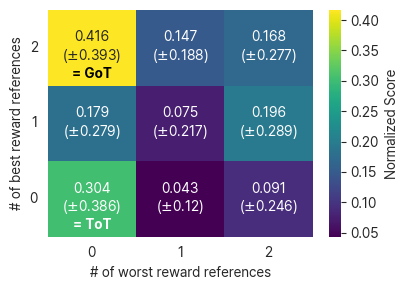

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# use font pretendard
plt.rcParams['font.family'] = 'Pretendard'

# 🔄 x,y 축 교환
heatmap_data = avg_df.pivot(index='n_aux_best', columns='n_aux_worst', values='mean')
std_data = avg_df.pivot(index='n_aux_best', columns='n_aux_worst', values='std')

# annot용 문자열 (±는 수식으로 조금 작게)
annot_data = heatmap_data.round(3).astype(str) + "\n" + \
             "($\\pm$" + std_data.round(3).astype(str) + ")"

plt.figure(figsize=(4.2, 3.0))
ax = sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt="",
    cbar_kws={'label': 'Normalized Score'},
    cmap="viridis"
)

plt.xlabel('# of worst reward references')   # 🔄 x축이 worst
plt.ylabel('# of best reward references')    # 🔄 y축이 best
plt.xticks(rotation=0)
plt.yticks(rotation=0)
ax.invert_yaxis()  # (0,0)이 좌상단에 오도록 유지

# === 셀 배경색에 따라 텍스트 색 결정 ===
def get_contrasting_text_color(rgba):
    r, g, b, _ = rgba
    luminance = 0.299*r + 0.587*g + 0.114*b
    return "black" if luminance > 0.5 else "white"

# facecolors
facecolors = ax.collections[0].get_facecolors()
ncols = heatmap_data.shape[1]

# 바뀐 축에 맞춰 좌표 재계산
tot_idx = 0 * ncols + 0   # (best=0, worst=0)
got_idx = 2 * ncols + 0   # (best=2, worst=0)  ← 교환 후

# ToT
ax.text(
    0 + 0.5, 0 + 0.5 - 0.25,
    "= ToT", ha='center', va='top',
    color='white', fontsize=10, fontweight="bold", # italic
    fontstyle='italic'
)

# GoT
ax.text(
    0 + 0.5, 2 + 0.5 - 0.25,
    "= GoT", ha='center', va='top',
    color='black', fontsize=10, fontweight="bold",
    fontstyle='italic'
)

plt.tight_layout()
plt.savefig('aux_fig.pdf', dpi=300)
plt.show()